В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any

def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
raw_df = pd.read_csv("data/train.csv", index_col=0)

In [3]:
train_df, val_df = split_train_val(
    raw_df.iloc[:, 2:],
    target_col="Exited",
    test_size=0.2,
    random_state=42
)

In [4]:
train_inputs, train_targets = separate_inputs_targets(
    train_df,
    list(train_df.columns[:-1]),
    "Exited"
)

In [5]:
val_inputs, val_targets = separate_inputs_targets(
    val_df,
    list(val_df.columns[:-1]),
    "Exited"
)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [6]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      12000 non-null  float64
 1   Geography        12000 non-null  object 
 2   Gender           12000 non-null  object 
 3   Age              12000 non-null  float64
 4   Tenure           12000 non-null  float64
 5   Balance          12000 non-null  float64
 6   NumOfProducts    12000 non-null  float64
 7   HasCrCard        12000 non-null  float64
 8   IsActiveMember   12000 non-null  float64
 9   EstimatedSalary  12000 non-null  float64
dtypes: float64(8), object(2)
memory usage: 1.0+ MB


In [7]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

In [8]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 7180 to 9360
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      12000 non-null  float64 
 1   Geography        12000 non-null  category
 2   Gender           12000 non-null  category
 3   Age              12000 non-null  float64 
 4   Tenure           12000 non-null  float64 
 5   Balance          12000 non-null  float64 
 6   NumOfProducts    12000 non-null  float64 
 7   HasCrCard        12000 non-null  float64 
 8   IsActiveMember   12000 non-null  float64 
 9   EstimatedSalary  12000 non-null  float64 
dtypes: category(2), float64(8)
memory usage: 867.4 KB


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [9]:
xgb_clf = xgb.XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
)

xgb_clf.fit(train_inputs, train_targets)

train_pred = xgb_clf.predict(train_inputs)
val_pred = xgb_clf.predict(val_inputs)

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

train_pred_proba = xgb_clf.predict_proba(train_inputs)[:, 1]
val_pred_proba = xgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred_proba)
val_auc = roc_auc_score(val_targets, val_pred_proba)

print("Train AUROC:", round(train_auc, 4))
print("Val AUROC:", round(val_auc, 4))

              precision    recall  f1-score   support

         0.0     0.9164    0.9614    0.9384      9558
         1.0     0.8130    0.6568    0.7266      2442

    accuracy                         0.8994     12000
   macro avg     0.8647    0.8091    0.8325     12000
weighted avg     0.8954    0.8994    0.8953     12000

              precision    recall  f1-score   support

         0.0     0.9174    0.9569    0.9367      2390
         1.0     0.7968    0.6623    0.7234       610

    accuracy                         0.8970      3000
   macro avg     0.8571    0.8096    0.8300      3000
weighted avg     0.8929    0.8970    0.8933      3000

Train AUROC: 0.9344
Val AUROC: 0.9334


C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:54:34] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


**Висновок**
- Модель хороша - Вона вже дає високу якість без жодного тюнінгу.
- High variance? Ні. Різниця між train і val = 0.001 - модель стабільна.
- High bias? Ні. AUROC > 0.93 — це дуже добре.

**DecisionTree**
- Train AUROC: 0.9257
- Val AUROC: 0.9219
  
**XGBoost**
- Train AUROC: 0.9344
- Val AUROC: 0.9334

Обидві моделі дають хороший AUROC на валідації — це дуже сильний результат.
- XGBoost — кращий, але не радикально.
- DecisionTree — surprisingly strong baseline для даних.
- Жодна модель не має high bias чи variance — дані добре піддаються моделюванню.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [26]:
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=int(params['min_child_weight']), # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'], # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'], # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'], # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'], # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        tree_method="hist",   # найшвидший варіант на CPU
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False
    )

    pred_proba = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, pred_proba)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 200, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [ ]:
%%time
# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials);

In [28]:
# Перетворення типів
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри:")
print(pd.DataFrame(best.items(), columns=["Parameter", "Value"]))

Найкращі гіперпараметри:
          Parameter       Value
0  colsample_bytree    0.707888
1             gamma    0.335336
2     learning_rate    0.057815
3         max_depth    3.000000
4  min_child_weight    3.000000
5      n_estimators  175.000000
6         reg_alpha    0.389842
7        reg_lambda    0.096778
8         subsample    0.694466


In [29]:
# Фінальна модель
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    tree_method="hist"
)

final_clf.fit(train_inputs, train_targets);

C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:39] WARNING: C:\b\abs_90_bwj_86a\croot\xgboost-split_1724073762025\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [30]:
train_pred = final_clf.predict(train_inputs)
val_pred = final_clf.predict(val_inputs)

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

train_pred_proba = final_clf.predict_proba(train_inputs)[:, 1]
val_pred_proba = final_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred_proba)
val_auc = roc_auc_score(val_targets, val_pred_proba)

print("Train AUROC:", round(train_auc, 4))
print("Val AUROC:", round(val_auc, 4))

              precision    recall  f1-score   support

         0.0     0.9244    0.9643    0.9439      9558
         1.0     0.8319    0.6912    0.7551      2442

    accuracy                         0.9087     12000
   macro avg     0.8782    0.8278    0.8495     12000
weighted avg     0.9056    0.9087    0.9055     12000

              precision    recall  f1-score   support

         0.0     0.9215    0.9573    0.9391      2390
         1.0     0.8027    0.6803    0.7365       610

    accuracy                         0.9010      3000
   macro avg     0.8621    0.8188    0.8378      3000
weighted avg     0.8973    0.9010    0.8979      3000

Train AUROC: 0.9432
Val AUROC: 0.9376


**Висновок**
1. Ручний XGBoost
- Train: 0.9344
- Val: 0.9334
- Різниця: 0.0010 - модель дуже стабільна
- Якість: дуже висока
- Це вже сильна модель.
2. Hyperopt XGBoost
- Train: 0.9432
- Val: 0.9376
- Різниця: 0.0056 - трохи більша, але все ще дуже мала
- Якість: ще вища

Hyperopt:
- зменшив глибину дерева (max_depth=3)
- збільшив регуляризацію (reg_alpha, reg_lambda)
- підібрав оптимальну кількість дерев (n_estimators=175)
- підібрав learning_rate ≈ 0.058
- Це зробило модель стабільною, гладкою і дуже точною.

In [31]:
test_df = pd.read_csv("data/test.csv", index_col=0)
test_df = test_df.iloc[:, 2:]
test_df[cat_features] = test_df[cat_features].astype('category')
test_df['Exited'] = final_clf.predict_proba(test_df)[:, 1]
test_df = test_df.reset_index()
submission = pd.read_csv("data/sample_submission.csv")
submission['Exited'] = test_df['Exited']
submission.to_csv("data/submission_XGBoost_drop_surname.csv", index=False)

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [32]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_features]

In [36]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    categorical_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    missing=np.nan,  # явне вказування пропущених значень
)

In [37]:
lgb_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
)

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


LGBMClassifier(categorical_feature=[1, 2], max_depth=3, missing=nan,
               n_estimators=50)

In [38]:
train_pred = lgb_clf.predict(train_inputs)
val_pred = lgb_clf.predict(val_inputs)

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

train_pred_proba = lgb_clf.predict_proba(train_inputs)[:, 1]
val_pred_proba = lgb_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred_proba)
val_auc = roc_auc_score(val_targets, val_pred_proba)

print("Train AUROC:", round(train_auc, 4))
print("Val AUROC:", round(val_auc, 4))

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
              precision    recall  f1-score   support

         0.0     0.9184    0.9632    0.9403      9558
         1.0     0.8219    0.6650    0.7352      2442

    accuracy                         0.9025     12000
   macro avg     0.8701    0.8141    0.8377     12000
weighted avg     0.8988    0.9025    0.8985     12000

              precision    recall  f1-score   support

         0.0     0.9175    0.9590    0.9378      2390
         1.0     0.8048    0.6623    0.7266       610

    accuracy                         0.8987      3000
   macro avg     0.8612    0.8106    0.8322      3000
weighted avg     0.8946    0.8987    0.8949      3000

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
Train AUROC: 0.9388
Val AUROC: 0.9362


**Висновок**

LightGBM модель хороша:
- Високий AUC на тренуванні
- Високий AUC на валідації
- Різниця всього 0.0026 - модель не перенавчена
- Немає high bias. AUC > 0.93 - модель добре вчиться

**Порівняння з XGBoost**

Твоя найкраща XGBoost‑модель (Hyperopt):
- Train AUROC: 0.9432
- Val AUROC: 0.9376

LightGBM:
- Train AUROC: 0.9388
- Val AUROC: 0.9362

LightGBM у базовій конфігурації вже майже наздогнав XGBoost після Hyperopt‑тюнінгу.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [44]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']), # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'], # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']), # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']), # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'], # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        min_data_in_leaf = int(params['min_data_in_leaf']),
        subsample=params['subsample'], # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'], # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'], # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'], # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'], # Мінімальне зменшення втрат, необхідне для виконання поділу
        categorical_feature=cat_feature_indexes, # Індекси категорійних ознак
        missing=np.nan,
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        eval_metric="auc",
        #verbose=False
    )

    pred_proba = clf.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, pred_proba)

    return {'loss': -auc, 'status': STATUS_OK}


# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 200, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.1),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 100, 1),
    'min_child_weight': hp.uniform('min_child_weight', 5, 50),
    'min_data_in_leaf': hp.quniform('min_data_in_leaf', 50, 300, 10),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}

In [ ]:
# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

In [46]:
# Перетворення типів
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])

print("Найкращі гіперпараметри:")
print(pd.DataFrame(best.items(), columns=["Parameter", "Value"]))

Найкращі гіперпараметри:
           Parameter       Value
0   colsample_bytree    0.939373
1      learning_rate    0.073085
2          max_depth    3.000000
3   min_child_weight   13.354882
4   min_data_in_leaf  290.000000
5     min_split_gain    0.019725
6       n_estimators  325.000000
7         num_leaves   54.000000
8          reg_alpha    0.650333
9         reg_lambda    0.101171
10         subsample    0.824356


In [47]:
# Фінальна модель
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    categorical_feature=cat_feature_indexes,
    missing=np.nan
)

final_clf.fit(train_inputs, train_targets)

C:\Users\mariy\anaconda3\envs\py312\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] categorical_feature is set=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMClassifier(categorical_feature=[1, 2],
               colsample_bytree=np.float64(0.9393730801052107),
               learning_rate=np.float64(0.07308505674151515), max_depth=3,
               min_child_weight=np.float64(13.354881569994077),
               min_split_gain=np.float64(0.019724570320459545), missing=nan,
               n_estimators=325, num_leaves=54,
               reg_alpha=np.float64(0.6503327744024937),
               reg_lambda=np.float64(0.10117068141954555),
               subsample=np.float64(0.8243564026497721))

In [48]:
train_pred = final_clf.predict(train_inputs)
val_pred = final_clf.predict(val_inputs)

print(classification_report(train_targets, train_pred, digits=4))
print(classification_report(val_targets, val_pred, digits=4))

train_pred_proba = final_clf.predict_proba(train_inputs)[:, 1]
val_pred_proba = final_clf.predict_proba(val_inputs)[:, 1]

train_auc = roc_auc_score(train_targets, train_pred_proba)
val_auc = roc_auc_score(val_targets, val_pred_proba)

print("Train AUROC:", round(train_auc, 4))
print("Val AUROC:", round(val_auc, 4))

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
              precision    recall  f1-score   support

         0.0     0.9278    0.9657    0.9464      9558
         1.0     0.8402    0.7060    0.7672      2442

    accuracy                         0.9128     12000
   macro avg     0.8840    0.8358    0.8568     12000
weighted avg     0.9100    0.9128    0.9099     12000

              precision    recall  f1-score   support

         0.0     0.9224    0.9594    0.9405      2390
         1.0     0.8113    0.6836    0.7420       610

    accuracy                         0.9033      3000
   macro avg     0.8668    0.8215    0.8413      3000
weighted avg     0.8998    0.9033    0.9002      3000

[LightGBM] [Warning] Unknown parameter: missing
[LightGBM] [Warning] Unknown parameter: missing
Train AUROC: 0.9487
Val AUROC: 0.9366


**Висновок**
Модель дуже сильна
- AUC на тренуванні високий
- AUC на валідації теж високий
- Різниця ≈ 0.0121 → модель трохи гнучкіша, але не перенавчена
- Немає high bias. AUC > 0.93 на обох наборах

**Загальний висновок**
- Hyperopt‑LightGBM — дуже сильна модель
- Вона трохи краща за базовий LightGBM
- Вона майже дорівнює XGBoost за якістю
- Модель збалансована, без перенавчання

LightGBM - трошки більш гнучкіша і легше перенавчається. Однак вона теж дає хороші результати в нашій задачі. Тож я додам обивда результати до змагання.

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

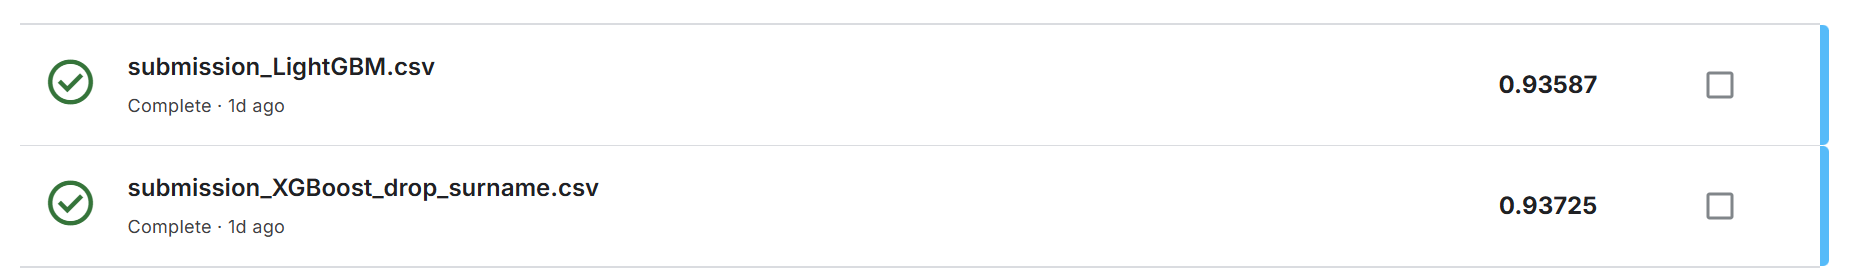

In [50]:
test_df = pd.read_csv("data/test.csv", index_col=0)
test_df = test_df.iloc[:, 2:]
cat_features = ['Geography', 'Gender']
test_df[cat_features] = test_df[cat_features].astype('category')
test_df['Exited'] = final_clf.predict_proba(test_df)[:, 1]
test_df = test_df.reset_index()
submission = pd.read_csv("data/sample_submission.csv")
submission['Exited'] = test_df['Exited']
submission.to_csv("data/submission_LightGBM.csv", index=False)

[LightGBM] [Warning] Unknown parameter: missing
